<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana1/CargadeDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
a = 7
a

7

In [2]:
# Como cargar el drive en python, comment
# Sintaxis -> una forma de escribir

from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Necesitamos explorar la estructura de directorios
import os
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_MachineLearning/Semana1/')

In [4]:
# Donde estoy, la admiracion significa que es linux
!pwd

/content/drive/MyDrive/EDCO_MachineLearning/Semana1


In [5]:
# Que hay???
!ls  # Esto es busqueda recursiva

CargadeDatos.ipynb  Data


In [6]:
# Cargamos nuestros datos
import pandas as pd

In [9]:
Data = pd.read_csv('Data/MediaMovilData.csv', sep=',')

In [11]:
type(Data)

pandas.core.frame.DataFrame

In [14]:
Data.shape
# Las filas: el numero de datos que tenemos
# Las columnas: el numero de caracteristicas

(18, 1)

In [16]:
# Necesitamos la informacion
x = Data['Ventas'].values
# esto es una lista
x

array([1250, 1150,  970, 1100, 1170, 1080, 1120, 1230, 1210, 1050, 1030,
        990, 1160, 1200, 1180, 1260, 1230, 1190])

In [23]:
np.arange(1,len(x)+1,1)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

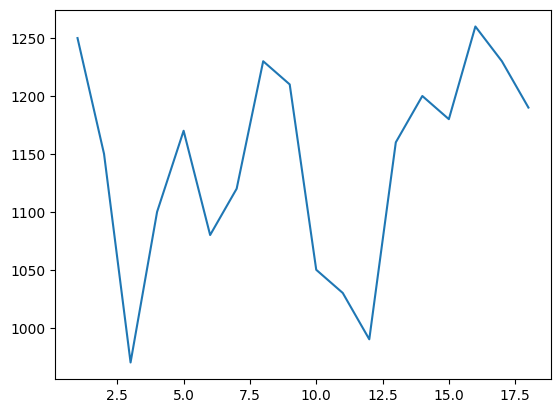

In [24]:
# La graficación es muy importante!!!!
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(1,len(x)+1,1),x)
plt.show()

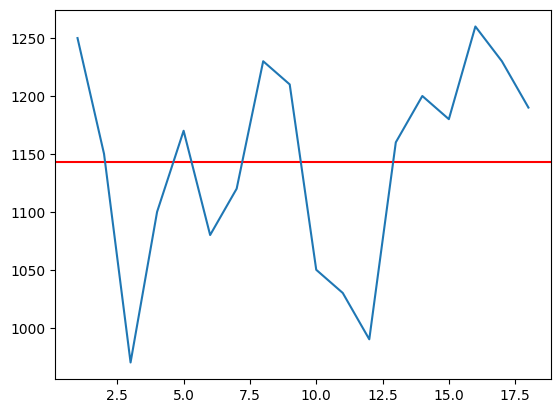

In [28]:
# QUiere saber cuánto va a vender al siguiente dia? día 19
# calcular le promedio
media = np.mean( x )
plt.axhline(y=media, color='r', linestyle='-')
plt.plot(np.arange(1,len(x)+1,1),x)
plt.show()

In [29]:
# Este es un modelo demasiado SIMPLE para describir lo que pasa: Este es un caso de underfitting!
# Entonces si el modelo es muy simple -> complejizar el modelo

In [30]:
# Definir una funcion
def GetMediaMovil(x,n):
  # Los datos y el numero de dias

  # GUardamos
  media = np.zeros( len(x) + 1 )

  for i in range( len(media) ):

    sum_ = 0.

    if i >= n:

      for j in range( i-n, i ):

        sum_ += x[j]

      media[i] = sum_/n # Promedio aritmetico

    else:
      media[i] = x[i]

  return media

In [58]:
media_ = GetMediaMovil(x,3) # Usamos 3 dias
media_[-1] # Deme el ultimo

np.float64(1226.6666666666667)

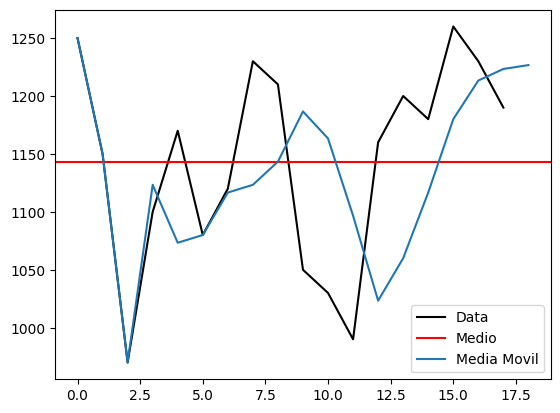

In [59]:
media = np.mean( x )
plt.plot(x, color='k',label='Data')
plt.axhline(y=media, color='r', linestyle='-', label='Medio')
plt.plot(media_, label='Media Movil')
plt.legend()
plt.show()

In [60]:
# Definir una funcion para hacer una media movil ponderada

def GetWeightedMediaMovil(x,w):
  # Los datos y del vector de pesos
  # Hacer un modelo parametrico

  n = len(w)

  # GUardamos
  media = np.zeros( len(x) + 1 )

  for i in range( len(media) ):

    sum_ = 0.

    if i >= n:

      k = 0

      for j in range( i-n, i ):

        sum_ += w[k]*x[j]
        k += 1

      media[i] = sum_ # Promedio pesado

    else:
      media[i] = x[i]

  return media

In [82]:
# Definamos un posible modelo
w = np.array([0.05,0.15,0.8])
Wmedia_ = GetWeightedMediaMovil(x,w)
Wmedia_[-1] # Deme el ultimo

np.float64(1199.5)

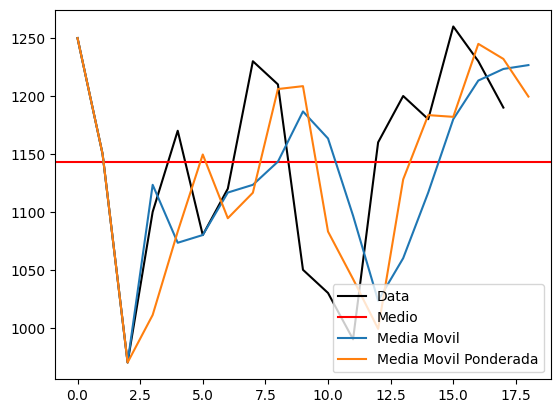

In [83]:
media = np.mean( x )
plt.plot(x, color='k',label='Data')
plt.axhline(y=media, color='r', linestyle='-', label='Medio')
plt.plot(media_, label='Media Movil')
plt.plot(Wmedia_, label='Media Movil Ponderada')
plt.legend()
plt.show()

In [84]:
# Como encontramos el mejor modelo posible?
# Queremos que el modelo de media movil se equivoque "en promedio" lo menos posible

In [85]:
def GetError(x,y):
  # X es el muestreo (Datos)
  # Y es el valor que predice el modelo
  return np.mean( np.abs(x-y) )

In [86]:
GetError(x,Wmedia_[-1])

np.float64(77.05555555555556)

In [87]:
# Como encontramos el mejor posible?